In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from modified_rf import RandomForestRegressor621

In [4]:
def read_label_data(name, ID):
    data = pd.read_csv(name)
    data
    X = data.iloc[0:,2:].to_numpy()
    X = np.column_stack((X,[ID]*len(X)))
    y = data.iloc[0:,1].to_numpy()
    return X, y

In [5]:
X, y = read_label_data('Data/TMB_F1CDX_data.xlsx - thca_tcga_pub.csv', 0)

Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - blca_tcga_pub.csv', 1)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - ov_tcga_pub.csv', 2)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - kich_tcga_pub.csv', 3)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - coadread_tcga_pub.csv', 4)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - kirc_tcga_pub.csv', 5)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - sarc_tcga_pub.csv', 6)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - brca_tcga_pub.csv', 7)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - hnsc_tcga_pub.csv', 9)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - ucec_tcga_pub.csv', 10)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - luad_tcga_pub.csv', 11)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - lusc_tcga_pub.csv', 12)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - gbm_tcga_pub.csv', 13)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - prad_tcga_pub.csv', 14)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
print(X_train[:,-1])

[ 5. 14.  7. ...  7.  2.  0.]


In [6]:
def forest(label_depth):

    rf1 = RandomForestRegressor621(n_estimators=100, min_samples_leaf=10, max_features=0.2, max_depth=None, label_depth=label_depth, force_label_split=False)
    # Fit the model to the training data
    rf1.fit(X_train, y_train)

    # Make predictions on new data
    predictions = rf1.predict(X_test)

    # Calculate the accuracy score for the predictions
    accuracy_score = rf1.score(X_test, y_test)
    print("\n Test Accuracy:",accuracy_score)

    train_score = rf1.score(X_train, y_train)
    print("\n Training Accuracy:",train_score)

    return train_score, accuracy_score

In [7]:
depth = 25
test_scores = np.zeros(depth)
train_scores = np.zeros(depth)
for i in range(0,depth):
    train_scores[i], test_scores[i] = forest(i)
    print(i)

Tree: 99
 Test Accuracy: 0.09303082000437901

 Training Accuracy: 0.3628224583848594
0
Tree: 99
 Test Accuracy: 0.12660694604028522

 Training Accuracy: 0.3592207667131341
1
Tree: 99
 Test Accuracy: 0.11442085482307185

 Training Accuracy: 0.36946714135858216
2
Tree: 99
 Test Accuracy: 0.10470484107836187

 Training Accuracy: 0.3593428197096342
3
Tree: 99
 Test Accuracy: 0.08983394811318557

 Training Accuracy: 0.352123093085285
4
Tree: 99
 Test Accuracy: 0.099695720828465

 Training Accuracy: 0.39663356276113915
5
Tree: 99
 Test Accuracy: 0.13603714128715105

 Training Accuracy: 0.3674240814475116
6
Tree: 99
 Test Accuracy: 0.12261183929980946

 Training Accuracy: 0.3692970214397795
7
Tree: 99
 Test Accuracy: 0.09661144390926346

 Training Accuracy: 0.3539343772557966
8
Tree: 99
 Test Accuracy: 0.10640247188994878

 Training Accuracy: 0.35946978040759303
9
Tree: 99
 Test Accuracy: 0.09454010167147853

 Training Accuracy: 0.35172896570157597
10
Tree: 99
 Test Accuracy: 0.10323835830069

In [8]:
# Create an instance of RandomForestClassifier from scikit-learn
sklearn_rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=10, max_depth=None, max_features = 0.2)

# Fit the scikit-learn model to the training data
sklearn_rf.fit(X_train, y_train)

# Make predictions using the scikit-learn model
sklearn_predictions = sklearn_rf.predict(X_test)

# Calculate the accuracy score for the scikit-learn predictions
sk_accuracy_score = sklearn_rf.score(X_test, y_test)
print("\n Test Accuracy:",sk_accuracy_score)
sk_test = [sk_accuracy_score]*depth


sk_train_score = sklearn_rf.score(X_train, y_train)
print("\n Training Accuracy:",sk_train_score)
sk_train = [sk_train_score]*depth



 Test Accuracy: 0.09542900353361483

 Training Accuracy: 0.30622809781852234


In [9]:
rf_unlabeled = RandomForestRegressor621(n_estimators=100, min_samples_leaf=10, max_features=0.2, max_depth=None, label_depth=None, force_label_split=False)
# Fit the model to the training data
rf_unlabeled.fit(X_train, y_train)

# Make predictions on new data
predictions = rf_unlabeled.predict(X_test)

# Calculate the accuracy score for the predictions
accuracy_score = rf_unlabeled.score(X_test, y_test)
print("\n Test Accuracy:",accuracy_score)
rf_unlabeled_test = [accuracy_score]*depth
train_score = rf_unlabeled.score(X_train, y_train)
print("\n Training Accuracy:",train_score)

Tree: 99
 Test Accuracy: 0.12447761193111562

 Training Accuracy: 0.37737150472925596


Text(0, 0.5, 'Sk Test Accuracy')

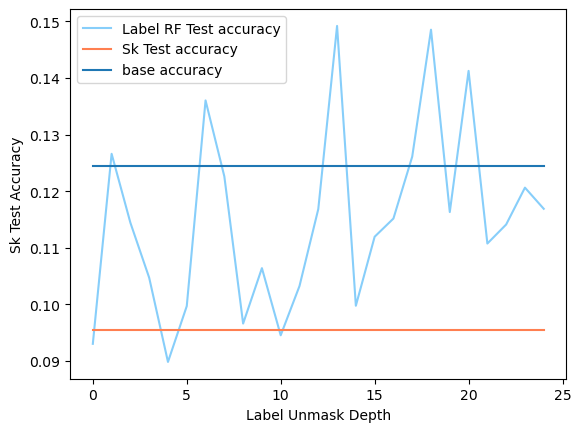

In [10]:
import matplotlib.pyplot as plt

plt.plot(np.arange(depth),test_scores, label = 'Label RF Test accuracy', color = "lightskyblue")
#plt.plot(np.arange(depth),train_scores, label = 'Label Training accuracy', color = "dodgerblue")

plt.plot(np.arange(depth),sk_test, label = 'Sk Test accuracy', color = "coral")
#plt.plot(np.arange(depth),sk_train, label = 'Sk Training accuracy', color = "firebrick")

plt.plot(np.arange(depth), rf_unlabeled_test, label = 'base accuracy')

plt.legend()
plt.xlabel("Label Unmask Depth")
plt.ylabel("Sk Test Accuracy")